# Protein Function Prediction

# 🧬 Problem Identification

## Definition :
Given a protein's amino acid sequence, we will predict which Gene Ontology (GO) terms describe its biological function. Each protein can have **multiple functions simultaneously**, making this a **multi-label classification problem**.

## Real-World Impact :
Proteins are the molecular machines of life — they drive metabolism, immune response, cell division, and disease. Yet the vast majority of sequenced proteins have unknown functions. As of 2024, UniProtKB contains over **250 million protein sequences**, but fewer than **0.5% have been experimentally annotated**. *(UniProt Consortium, 2025)*

> UniProt Consortium. (2025). UniProt: the Universal Protein Knowledgebase in 2025.
> *Nucleic Acids Research*, 53(D1), D609–D617. https://doi.org/10.1093/nar/gkae1010

Accurate computational prediction of protein function directly accelerates:
-  **Drug discovery** — identifying disease-relevant protein targets
-  **Genetic disease research** — linking mutations to functional loss
-  **Vaccine development** — characterizing pathogen proteins
-  **Synthetic biology** — designing proteins with desired functions

## Problem Formulation :
| | |
|---|---|
| **Input** | Amino acid sequence of a protein (e.g. `MKTAYIAKQRQISFVKSHFS...`) |
| **Output** | A set of GO terms across 3 branches |
| **Label space** | 40,000+ GO terms organized as a Directed Acyclic Graph (DAG) |
| **Challenge** | Extreme multi-label, hierarchical, highly imbalanced labels |

### GO Term Branches (Aspects) :
| Branch | Code | Description |
|---|---|---|
| Biological Process | BPO | What process the protein drives |
| Molecular Function | MFO | What the protein does chemically |
| Cellular Component | CCO | Where in the cell it operates |

## Datasets :
| # | Dataset | Proteins |
|---|---|---|
| 1 | Human Protein Sequences & Annotations | 70,956 |
| 2 | Protein Sequences with GO Annotations | 81,000 |
| 3 | CAFA5 — Critical Assessment of Function Annotation | 142,246 |

## Experimental Setup — 3×3 Grid :
|  | Dataset 1 | Dataset 2 | Dataset 3 |
|---|---|---|---|
| **Logistic Regression** | ✓ | ✓ | ✓ |
| **Linear SVM** | ✓ | ✓ | ✓ |
| **CNN** | ✓ | ✓ | ✓ |

## Evaluation Metrics :
| Metric | Role |
|---|---|
| **AUPR** | Primary — best for imbalanced multi-label problems |
| **Fmax** | Maximum F1 across all thresholds — CAFA standard |
| **Macro F1** | Treats rare and common GO terms equally |
| **Micro F1** | Overall pooled performance |
| **AUROC** | Discriminative ability across all labels |
| **Hamming Loss** | Fraction of labels incorrectly predicted |

# Algorithm Selection

---

### Algorithm 1 — Logistic Regression (OneVsRest)
**Classification:** Linear probabilistic baseline

**Justification:**
- The standard baseline for multi-label classification — any stronger model must beat it
- OneVsRest trains one binary LR classifier per GO term, directly modeling the multi-label structure
- Outputs calibrated probabilities, making it compatible with threshold-based metrics (Fmax, AUPR)
- Interpretable — coefficients reveal which k-mer features drive each GO term prediction
- Computationally efficient, making it feasible across all 3 datasets

**Relevance to protein function:** LR with sequence-derived features has been used in protein function prediction since the early 2000s and remains a strong baseline in CAFA evaluations.

---

### Algorithm 2 — Linear SVM (OneVsRest + Calibration)
**Classification:** Linear maximum-margin classifier

**Justification:**
- SVMs are state-of-the-art for high-dimensional sparse feature spaces — exactly what k-mer vectors produce (8,000 features, <3% density)
- Maximum-margin training is more robust to the severe class imbalance in GO term data than LR
- `CalibratedClassifierCV` wraps `LinearSVC` to produce probabilities needed for AUPR and Fmax
- OneVsRest decomposition is well-established for multi-label SVM in bioinformatics
- Consistently outperforms LR on text-like sparse feature representations (k-mers are analogous to n-grams in NLP)

**Relevance to protein function:** SVMs have been a dominant method in protein function prediction for over a decade, used in tools like GOtcha and ProFAT, and remain competitive baselines in modern CAFA challenges.

---

### Algorithm 3 — Convolutional Neural Network (CNN)
**Classification:** Deep learning, non-linear function approximator

**Justification:**
- Neural networks can learn non-linear combinations of k-mer features that linear models cannot capture
- `BCEWithLogitsLoss` is the correct loss function for multi-label problems — applies independent sigmoid per label rather than softmax, allowing multiple labels to be active simultaneously
- Batch normalization and dropout regularize against overfitting on sparse label spaces
- Scales naturally to large label counts without the OneVsRest decomposition overhead
- Directly comparable to LR and SVM since all three use identical k-mer input features — isolating model capacity as the only variable

**Relevance to protein function:** Deep learning models (DeepGO, ProteinBERT, ESM2-based models) represent the current state-of-the-art in protein function prediction. This CNN serves as a stepping stone toward transformer-based approaches.

---

## Algorithm Comparison Summary

| Property | Logistic Regression | Linear SVM | CNN |
|---|---|---|---|
| **Type** | Linear | Linear (max-margin) | Non-linear (deep) |
| **Multi-label strategy** | OneVsRest | OneVsRest | Native (sigmoid per label) |
| **Handles non-linearity** | ✗ | ✗ | ✓ |
| **Probability output** | ✓ | ✓ (calibrated) | ✓ (sigmoid) |
| **Interpretability** | High | Medium | Low |
| **Training speed** | Fast | Fast | Slow |
| **State-of-the-art** | Baseline | Strong baseline | Current direction |

## Why These Three Together
The three algorithms form a deliberate progression from simple to complex:
- **LR** establishes the minimum acceptable performance
- **SVM** tests whether a stronger linear model adds value
- **CNN** tests whether non-linearity is necessary for this problem

If SVM ≈ CNN >> LR → the problem is linearly separable from k-mer features  
If CNN >> SVM >> LR → non-linearity is important and deeper models are warranted  
If all three ≈ equal → k-mer features are the bottleneck, not the model

# Modelling as an Optimization Problem

## Objective

The goal is to learn a function $f: \mathcal{X} \rightarrow \{0,1\}^L$ that maps a
protein's k-mer feature vector to a binary vector of GO term assignments,
minimising prediction error across all $L$ GO terms simultaneously.

---

## Notation

| Symbol | Definition |
|---|---|
| $N$ | Number of proteins in the training set |
| $L$ | Number of GO terms (labels) |
| $\mathbf{x}_i \in \mathbb{R}^d$ | k-mer feature vector of protein $i$, where $d = 400$ |
| $\mathbf{y}_i \in \{0,1\}^L$ | True binary label vector of protein $i$ |
| $\hat{\mathbf{y}}_i \in [0,1]^L$ | Predicted probability vector for protein $i$ |
| $\hat{y}_{il}$ | Predicted probability that protein $i$ has GO term $l$ |
| $y_{il}$ | True label — 1 if protein $i$ has GO term $l$, 0 otherwise |
| $\boldsymbol{\theta}$ | Model parameters to be learned |

---

## Core Objective Function

Since each GO term is an independent binary prediction, the objective is to
minimise the **Binary Cross-Entropy (BCE) loss** summed across all $N$ proteins
and $L$ labels:

$$Z(\boldsymbol{\theta}) = -\frac{1}{N \cdot L} \sum_{i=1}^{N} \sum_{l=1}^{L} \left[ y_{il} \log(\hat{y}_{il}) + (1 - y_{il}) \log(1 - \hat{y}_{il}) \right]$$

where the predicted probability for label $l$ of protein $i$ is obtained via
the sigmoid function:

$$\hat{y}_{il} = \sigma(f_l(\mathbf{x}_i; \boldsymbol{\theta})) = \frac{1}{1 + e^{-f_l(\mathbf{x}_i; \boldsymbol{\theta})}}$$

The **sigmoid** (not softmax) is used because GO terms are **not mutually
exclusive** — multiple labels can simultaneously equal 1.

In [107]:
import os
import io
import re
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iproduct
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, hamming_loss
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import ast # Import ast module for literal_eval

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [108]:
from Bio import SeqIO  # pip install biopython

# DATASET 1: Human Protein Sequences and Function Annotations

# Load FASTA sequences
dataset1_sequences = {}
fasta_path = "./data/Human Protein Sequences and Function Annotations/ALL-HUMAN-0001 SEQUENCES.fasta"
for record in SeqIO.parse(fasta_path, "fasta"):
    dataset1_sequences[record.id] = str(record.seq)

dataset1_seq_df = pd.DataFrame(list(dataset1_sequences.items()), columns=["protein_id", "sequence"])

# Load annotations
dataset1_annotations = pd.read_csv("./data/Human Protein Sequences and Function Annotations/ALL-HUMAN-0001-ANNOTATIONS.txt", sep="\t")

print("Dataset 1 - Sequences shape:", dataset1_seq_df.shape)
print(dataset1_seq_df.head())
print("\nDataset 1 - Annotations shape:", dataset1_annotations.shape)
print(dataset1_annotations.head())

Dataset 1 - Sequences shape: (70956, 2)
             protein_id                                           sequence
0  sp|P27361|MK03_HUMAN  MAAAAAQGGGGGEPRRTEGVGPGVPGEVEMVKGQPFDVGPRYTQLQ...
1  sp|P53779|MK10_HUMAN  MSLHFLYYCSEPTLDVKIAFCQGFDKQVDVSYIAKHYNMSKSKVDN...
2  sp|Q15049|MLC1_HUMAN  MTQEPFREELAYDRMPTLERGRQDPASYAPDAKPSDLQLSKRLPPC...
3  sp|Q9UHC1|MLH3_HUMAN  MIKCLSVEVQAKLRSGLAISSLGQCVEELALNSIDAEAKCVAVRVN...
4   sp|P0DMT0|MLN_HUMAN     MTGKNWILISTTTPKSLEDEIVGRLLKILFVIFVDLISIIYVVITS

Dataset 1 - Annotations shape: (68156, 1)
  P27361 GO:0005524; F:ATP binding; IEA:UniProtKB-KW.
0  P27361 GO:0016301; F:kinase activity; TAS:Reac... 
1  P27361 GO:0004707; F:MAP kinase activity; IDA:... 
2  P27361 GO:0019902; F:phosphatase binding; IPI:... 
3  P27361 GO:0004674; F:protein serine/threonine ... 
4  P53779 GO:0005524; F:ATP binding; IEA:UniProtK... 


In [109]:
# DATASET 2: Protein sequences with GO Annotations

dataset2 = pd.read_csv("./data/Protein sequences w GO Annotations/proteins.csv")

print("Dataset 2 shape:", dataset2.shape)
print(dataset2.head())

Dataset 2 shape: (81000, 37)
    Entry                                           Sequence  \
0  C0SPC1  MNIDMNWLGQLLGSDWEIFPAGGATGDAYYAKHNGQQLFLKRNSSP...   
1  O05512  MFKKHTISLLIIFLLASAVLAKPIEAHTVSPVNPNAQQTTKTVMNW...   
2  O06724  MKFATGELYNRMFVGLIIDDEKIMDLQKAEKKLFELETIPGSLIEC...   
3  O08394  MKETSPIPQPKTFGPLGNLPLIDKDKPTLSLIKLAEEQGPIFQIHT...   
4  O31616  MKRHYEAVVIGGGIIGSAIAYYLAKENKNTALFESGTMGGRTTSAA...   

                                             GO_list  \
0  ['cytoplasm [GO:0005737]', 'ATP binding [GO:00...   
1  ['extracellular region [GO:0005576]', 'mannan ...   
2  ['cytoplasm [GO:0005737]', 'acetylpyruvate hyd...   
3  ['cytosol [GO:0005829]', 'aromatase activity [...   
4  ['cytoplasm [GO:0005737]', 'FAD binding [GO:00...   

                                  GO       GO_id        GO_namespace  \
0             cytoplasm [GO:0005737]  GO:0005737  cellular_component   
1  extracellular region [GO:0005576]  GO:0005576  cellular_component   
2             cytoplasm [GO:00057

In [110]:
# DATASET 3: CAFA 5

# Training sequences
cafa_base = "./data/cafa-5-protein-function-prediction - Copy/"

cafa_train_sequences = {}
for record in SeqIO.parse(cafa_base + "Train/train_sequences.fasta", "fasta"):
    cafa_train_sequences[record.id] = str(record.seq)

cafa_train_seq_df = pd.DataFrame(list(cafa_train_sequences.items()), columns=["protein_id", "sequence"])

# Training labels (GO terms per protein)
cafa_train_terms = pd.read_csv(cafa_base + "Train/train_terms.tsv", sep="\t")

# Taxonomy info
cafa_taxonomy = pd.read_csv(cafa_base + "Train/train_taxonomy.tsv", sep="\t")

# Test sequences
cafa_test_sequences = {}
for record in SeqIO.parse(cafa_base + "Test (Targets)/testsuperset.fasta", "fasta"):
    cafa_test_sequences[record.id] = str(record.seq)

cafa_test_seq_df = pd.DataFrame(list(cafa_test_sequences.items()), columns=["protein_id", "sequence"])

print("CAFA5 - Train sequences:", cafa_train_seq_df.shape)
print("CAFA5 - Train terms:", cafa_train_terms.shape)
print("CAFA5 - Taxonomy:", cafa_taxonomy.shape)
print("CAFA5 - Test sequences:", cafa_test_seq_df.shape)
print("\nTrain terms sample:")
print(cafa_train_terms.head(10))

CAFA5 - Train sequences: (142246, 2)
CAFA5 - Train terms: (5363863, 3)
CAFA5 - Taxonomy: (142246, 2)
CAFA5 - Test sequences: (141864, 2)

Train terms sample:
      EntryID        term aspect
0  A0A009IHW8  GO:0008152    BPO
1  A0A009IHW8  GO:0034655    BPO
2  A0A009IHW8  GO:0072523    BPO
3  A0A009IHW8  GO:0044270    BPO
4  A0A009IHW8  GO:0006753    BPO
5  A0A009IHW8  GO:1901292    BPO
6  A0A009IHW8  GO:0044237    BPO
7  A0A009IHW8  GO:1901360    BPO
8  A0A009IHW8  GO:0008150    BPO
9  A0A009IHW8  GO:1901564    BPO


In [111]:
# Section 4: K-mer Feature Builder 

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
K = 2
all_kmers = ["".join(p) for p in iproduct(AMINO_ACIDS, repeat=K)]
kmer_index = {kmer: i for i, kmer in enumerate(all_kmers)}

def sequence_to_kmer_vector(seq, k=K):
    seq = str(seq).upper()
    vec = np.zeros(len(all_kmers), dtype=np.float32)
    total = 0
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in kmer_index:
            vec[kmer_index[kmer]] += 1
            total += 1
    if total > 0:
        vec /= total
    return vec

In [112]:
# Section 5: Dataset Loaders

# FASTA Parser

def parse_fasta(fasta_path):
    #Parse FASTA file → dict {protein_id: sequence}.
    sequences = {}
    current_id = None
    current_seq = []

    with open(fasta_path, encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            line = line.strip()

            if line.startswith(">"):
                # Save previous sequence
                if current_id:
                    sequences[current_id] = "".join(current_seq)

                # Extract UniProt ID (e.g., sp|P0DP23|...)
                match = re.search(r"\|(.*?)\|", line)
                current_id = match.group(1) if match else line[1:].split()[0]
                current_seq = []

            else:
                current_seq.append(line)

    # Save last sequence
    if current_id:
        sequences[current_id] = "".join(current_seq)

    print(f" Parsed {len(sequences):,} sequences")
    return sequences

In [113]:
# Dataset 1: Protein GO

def load_protein_go():
    
    # Dataset 1 — Protein Sequences with GO Annotations.
    
    print("\nLoading Dataset 1: protein_go")

    df = pd.read_csv("./data/Protein sequences w GO Annotations/proteins.csv",low_memory=False)

    print(f" Shape : {df.shape}")
    print(f" Columns : {df.columns.tolist()}")

    # Detect relevant columns
    def find_column(columns, keywords, default_idx):
        return next(
            (c for c in columns if any(k in c.lower() for k in keywords)),
            columns[default_idx]
        )

    seq_col = find_column(df.columns, ["seq", "sequence", "aa"], 0)
    go_col  = find_column(df.columns, ["go", "term", "annot", "function"], 1)

    print(f" Seq col : '{seq_col}'  |  GO col : '{go_col}'")

    # Parse GO column
    def parse_go_entry(go_entry):
        if pd.isna(go_entry) or not str(go_entry).strip():
            return []

        try:
            parsed = ast.literal_eval(go_entry)
            if not isinstance(parsed, list):
                parsed = [parsed]
        except (ValueError, SyntaxError):
            parsed = [go_entry]

        return [
            match.group(1)
            for item in parsed
            if (match := re.search(r"(GO:\d+)", str(item)))
        ]

    df["go_list"] = df[go_col].apply(parse_go_entry)
    df["sequence"] = df[seq_col].fillna("")

    result = df[["sequence", "go_list"]]
    print(f" Proteins: {len(result):,}")

    return result

In [114]:
# Dataset 2: CAFA5

def load_cafa5():
    
    # Dataset 2 — CAFA 5 Protein Function Prediction.
    
    print("\n Loading Dataset 2: cafa5")

    sequences = parse_fasta("./data/cafa-5-protein-function-prediction - Copy/Train/train_sequences.fasta")

    terms_df = pd.read_csv("./data/cafa-5-protein-function-prediction - Copy/Train/train_terms.tsv", sep="\t",
        header=None,
        names=["EntryID", "term", "aspect"]
    )

    go_map = terms_df.groupby("EntryID")["term"].apply(list).to_dict()
    print(f" GO map  : {len(go_map):,} proteins annotated")

    valid_ids = list(set(sequences) & set(go_map))

    df = pd.DataFrame({"sequence": [sequences[i] for i in valid_ids],"go_list": [go_map[i] for i in valid_ids]})

    print(f" Merged  : {len(df):,} proteins with sequence + GO terms")
    return df

In [115]:
# Dataset 3: Human Proteins

def load_human():
    
    # Dataset 3 — Human Protein Sequences and Function Annotations.
    
    print("\nLoading Dataset 3: human-protein")

    fasta_path = "./data/Human Protein Sequences and Function Annotations/ALL-HUMAN-0001 SEQUENCES.fasta"
    annot_path = "./data/Human Protein Sequences and Function Annotations/ALL-HUMAN-0001-ANNOTATIONS.txt"

    sequences = parse_fasta(fasta_path)

    # Preview annotation format
    
    print(" Annotation sample:")
    with open(annot_path, encoding="utf-8", errors="ignore") as fh:
        for _ in range(5):
            print(f"{fh.readline().strip()}")

    # Build GO map
    go_map = {}
    with open(annot_path, encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue

            protein_id = line.split(maxsplit=1)[0]
            terms = re.findall(r"(GO:\d+)", line)

            if terms:
                go_map.setdefault(protein_id, []).extend(terms)

    print(f" GO map  : {len(go_map):,} proteins annotated")

    valid_ids = list(set(sequences) & set(go_map))

    df = pd.DataFrame({"sequence": [sequences[i] for i in valid_ids], "go_list":  [go_map[i] for i in valid_ids],})

    print(f" Merged  : {len(df):,} proteins with sequence + GO terms")
    return df

In [116]:
# Shared Preprocessing

def prepare(name, df, min_label_freq=50, max_proteins=None):
    
   # Filter rare labels → k-mer features → binarize → train/test split.
    
    print(f"\n Preprocessing: {name} ")

    # Remove proteins with no GO terms 
    df = df[df["go_list"].apply(len) > 0].copy().reset_index(drop=True)

    # Optional sampling (for large datasets)
    if max_proteins and len(df) > max_proteins:
        print(f" Sampling {max_proteins:,} from {len(df):,} proteins ...")
        df = df.sample(n=max_proteins, random_state=42).reset_index(drop=True)

    # Frequency filtering of GO terms
    if not df.empty:
        term_counts = df["go_list"].explode().value_counts()
        frequent = set(term_counts[term_counts >= min_label_freq].index)

        df["go_list"] = df["go_list"].apply(lambda terms: [t for t in terms if t in frequent])
        df = df[df["go_list"].apply(len) > 0].reset_index(drop=True)
    else:
        frequent = set()

    print(f" Proteins : {len(df):,}")
    print(f" Frequent GO terms : {len(frequent):,} (≥{min_label_freq} proteins)")

    # Early exit if no data remains
    if df.empty:
        print(" No data remaining after filtering. Skipping feature generation.")
        empty = np.array([])
        return empty, empty, empty, empty

    # Feature extraction (k-mers)
    print(f" Building {K}-mer feature vectors")
    X = np.vstack([sequence_to_kmer_vector(seq) for seq in df["sequence"]]).astype(np.float32)

    # Label binarization
    mlb = MultiLabelBinarizer()
    y = mlb.fit_transform(df["go_list"])

    print(f" Feature matrix X : {X.shape}")
    print(f" Label matrix y : {y.shape} (density={y.mean():.4f})")

    # Train / Test split 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f" Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")

    return X_train, X_test, y_train, y_test

In [117]:
# Exploratory Data Analysis

def plot_eda(raw_datasets):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    colors = ["steelblue", "coral", "mediumseagreen"]

    for col, (name, df) in enumerate(raw_datasets.items()):
        df = df.copy()
        # Only plot if the dataframe is not empty
        if df.empty:
            axes[0, col].set_title(f"{name}\nNo data to plot")
            axes[1, col].set_title(f"{name}\nNo data to plot")
            continue

        df["num_go"]  = df["go_list"].apply(len)
        df["seq_len"] = df["sequence"].apply(len)

        # GO terms per protein
        axes[0, col].hist(df["num_go"], bins=40, color=colors[col], edgecolor="white")
        axes[0, col].set_title(f"{name}\nGO Terms per Protein")
        axes[0, col].set_xlabel("# GO terms")
        axes[0, col].set_ylabel("Count")

        # Sequence length
        axes[1, col].hist(df["seq_len"].clip(upper=2000), bins=40, color=colors[col], edgecolor="white", alpha=0.8)
        axes[1, col].set_title(f"{name}\nSequence Length (clipped 2000aa)")
        axes[1, col].set_xlabel("Length (aa)")
        axes[1, col].set_ylabel("Count")

    plt.suptitle("Exploratory Data Analysis — All 3 Datasets", fontsize=14)
    plt.tight_layout()
    plt.show()

In [118]:
# Evaluation Helper 
all_results = {}

def evaluate(ds_name, model_name, y_true, y_pred, y_prob=None):
    if y_true.size == 0:
        metrics = {"Micro F1": "N/A", "Macro F1": "N/A", "AUROC": "N/A", "AUPR": "N/A", "Fmax": "N/A", "Hamming Loss": "N/A"}
        all_results.setdefault(ds_name, {})[model_name] = metrics
        print(" No data to evaluate.")
        return metrics

    #  Core metrics 
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    hamming = hamming_loss(y_true, y_pred)

    # Probability-based metrics
    auroc, aupr, fmax = None, None, None
    if y_prob is not None and y_prob.size > 0:
        try:
            auroc = roc_auc_score(y_true, y_prob, average="micro")
        except ValueError:
            pass
        try:
            aupr = average_precision_score(y_true, y_prob, average="micro")
        except ValueError:
            pass
        # Fmax — best F1 across all thresholds
        best_f1 = 0
        for t in np.arange(0.05, 0.95, 0.05):
            y_pred_t = (y_prob >= t).astype(int)
            f = f1_score(y_true, y_pred_t, average="micro", zero_division=0)
            if f > best_f1:
                best_f1 = f
        fmax = best_f1

    metrics = {
        "Micro F1": round(micro_f1, 4),
        "Macro F1": round(macro_f1, 4),
        "AUROC": round(auroc, 4)  if auroc is not None else "N/A",
        "AUPR": round(aupr,  4)  if aupr  is not None else "N/A",
        "Fmax": round(fmax,  4)  if fmax  is not None else "N/A",
        "Hamming Loss": round(hamming, 4),
    }
    all_results.setdefault(ds_name, {})[model_name] = metrics

    print(f" Micro F1 : {micro_f1:.4f}")
    print(f" Macro F1 : {macro_f1:.4f}")
    print(f" AUROC : {auroc:.4f}"  if auroc is not None else "    AUROC        : N/A")
    print(f" AUPR : {aupr:.4f}"   if aupr  is not None else "    AUPR         : N/A")
    print(f" Fmax : {fmax:.4f}"   if fmax  is not None else "    Fmax         : N/A")
    print(f" Hamming Loss : {hamming:.4f}")

    return metrics

In [119]:
# CNN Architecture 

class ProteinCNN(nn.Module):
    
    """
    1D CNN over k-mer frequency vectors.
    Treats the feature vector as a 1D signal and applies
    two convolutional layers before a fully connected classifier.
    """
    
    def __init__(self, input_dim, num_labels, dropout = 0.3):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(1),              # → (batch, 256, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_labels)            # raw logits
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x.unsqueeze(1)))


def train_cnn(X_train, y_train, X_test, num_labels, epochs=15, batch_size=32, lr=1e-3, threshold = 0.3, dropout = 0.3):
    # Handle cases where X_train or y_train might be empty after preprocessing
    if X_train.size == 0 or y_train.size == 0:
        print(" Skipping CNN training: X_train or y_train is empty.")
        return np.array([]), np.array([]), [] # Return empty predictions, probabilities, and losses

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tr, y_tr),batch_size=batch_size, shuffle=True)

    model = ProteinCNN(X_train.shape[1], num_labels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.BCEWithLogitsLoss()
    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if (epoch + 1) % 5 == 0:
            print(f" Epoch {epoch+1:2d}/{epochs} | Loss: {avg:.4f} " f"| LR: {scheduler.get_last_lr()[0]:.5f}")

    model.eval()
    with torch.no_grad():
        logits = model(X_te.to(device)).cpu()
        y_prob = torch.sigmoid(logits).numpy()
        y_pred = (y_prob >= 0.5).astype(int)

    return model, y_pred, y_prob, losses

# ---Logistic Regression and SVM goes here---

In [120]:
'''
    def train_lr(X_train, y_train):
    """
    Train Logistic Regression with OneVsRest for multi-label classification.
    Returns: fitted OneVsRestClassifier
    """
    # ── PARTNER: implement here ──────────────────────────────
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs"),
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    return clf


def train_svm(X_train, y_train):
    """
    Train Linear SVM with OneVsRest + CalibratedClassifierCV for multi-label classification.
    Returns: fitted OneVsRestClassifier
    """
    # ── PARTNER: implement here ──────────────────────────────
    clf = OneVsRestClassifier(
        CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0)),
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    return clf
'''

'\n    def train_lr(X_train, y_train):\n    """\n    Train Logistic Regression with OneVsRest for multi-label classification.\n    Returns: fitted OneVsRestClassifier\n    """\n    # ── PARTNER: implement here ──────────────────────────────\n    clf = OneVsRestClassifier(\n        LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs"),\n        n_jobs=-1\n    )\n    clf.fit(X_train, y_train)\n    return clf\n\n\ndef train_svm(X_train, y_train):\n    """\n    Train Linear SVM with OneVsRest + CalibratedClassifierCV for multi-label classification.\n    Returns: fitted OneVsRestClassifier\n    """\n    # ── PARTNER: implement here ──────────────────────────────\n    clf = OneVsRestClassifier(\n        CalibratedClassifierCV(LinearSVC(max_iter=2000, C=1.0)),\n        n_jobs=-1\n    )\n    clf.fit(X_train, y_train)\n    return clf\n'


Loading Dataset 1: protein_go
 Shape : (81000, 37)
 Columns : ['Entry', 'Sequence', 'GO_list', 'GO', 'GO_id', 'GO_namespace', 'GO_parents', 'GO_children', 'seq_length', 'mol_weight', 'pI', 'gravy', 'instability', 'aromaticity', 'helix', 'turn', 'sheet', 'aa_A', 'aa_C', 'aa_D', 'aa_E', 'aa_F', 'aa_G', 'aa_H', 'aa_I', 'aa_K', 'aa_L', 'aa_M', 'aa_N', 'aa_P', 'aa_Q', 'aa_R', 'aa_S', 'aa_T', 'aa_V', 'aa_W', 'aa_Y']
 Seq col : 'Sequence'  |  GO col : 'GO_list'
 Proteins: 81,000

 Loading Dataset 2: cafa5
 Parsed 142,246 sequences
 GO map  : 142,247 proteins annotated
 Merged  : 142,246 proteins with sequence + GO terms

Loading Dataset 3: human-protein
 Parsed 70,956 sequences
 Annotation sample:
P27361 GO:0005524; F:ATP binding; IEA:UniProtKB-KW.
P27361 GO:0016301; F:kinase activity; TAS:Reactome.
P27361 GO:0004707; F:MAP kinase activity; IDA:UniProtKB.
P27361 GO:0019902; F:phosphatase binding; IPI:UniProtKB.
P27361 GO:0004674; F:protein serine/threonine kinase activity; TAS:Reactome.
 GO 

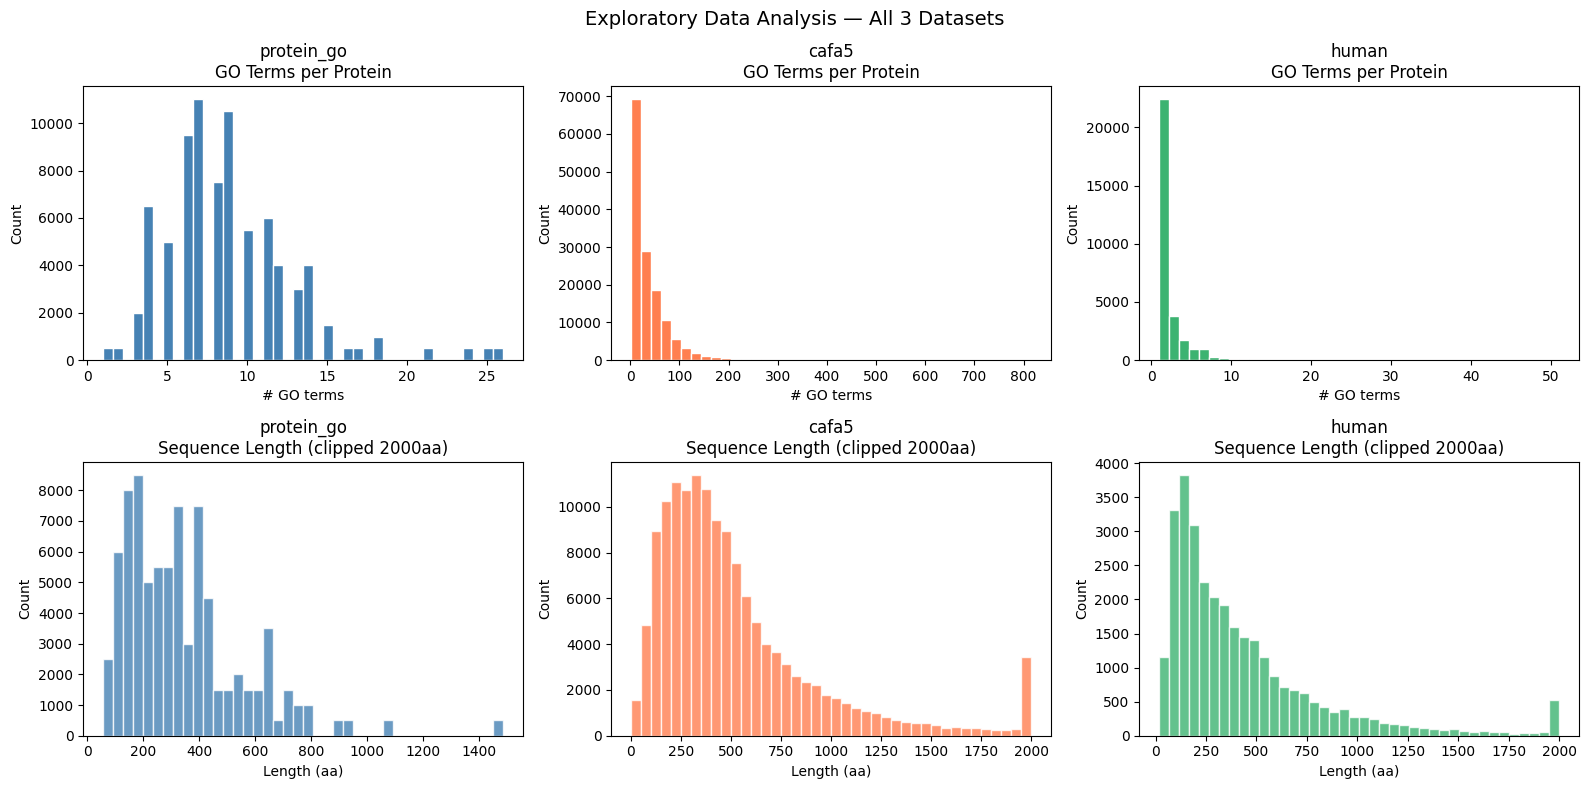


 Preprocessing: protein_go 
 Sampling 20,000 from 81,000 proteins ...
 Proteins : 20,000
 Frequent GO terms : 711 (≥50 proteins)
 Building 2-mer feature vectors
 Feature matrix X : (20000, 400)
 Label matrix y : (20000, 711) (density=0.0125)
 Train : 16,000 | Test : 4,000

 Preprocessing: cafa5 
 Sampling 20,000 from 142,246 proteins ...
 Proteins : 20,000
 Frequent GO terms : 1,753 (≥50 proteins)
 Building 2-mer feature vectors
 Feature matrix X : (20000, 400)
 Label matrix y : (20000, 1753) (density=0.0182)
 Train : 16,000 | Test : 4,000

 Preprocessing: human 
 Proteins : 25,365
 Frequent GO terms : 201 (≥50 proteins)
 Building 2-mer feature vectors
 Feature matrix X : (25365, 400)
 Label matrix y : (25365, 201) (density=0.0090)
 Train : 20,292 | Test : 5,073

 DATASET : protein_go
 Labels  : 711  |  Features : 400

 CNN
 Epoch  5/15 | Loss: 0.0287 | LR: 0.00050
 Epoch 10/15 | Loss: 0.0187 | LR: 0.00025
 Epoch 15/15 | Loss: 0.0154 | LR: 0.00013
 Trained in 23.4s
 Micro F1 : 0.6034


'\n     # Logistic Regression \n    print("\n  Logistic Regression")\n    t0     = time.time()\n    lr_clf = train_lr(X_train, y_train)\n    print(f"    Trained in {time.time()-t0:.1f}s")\n    evaluate(ds_name, "Logistic Regression",\n             y_test, lr_clf.predict(X_test), lr_clf.predict_proba(X_test))\n\n    # Linear SVM \n    print("\n  Linear SVM")\n    t0      = time.time()\n    svm_clf = train_svm(X_train, y_train)\n    print(f"    Trained in {time.time()-t0:.1f}s")\n    evaluate(ds_name, "Linear SVM",\n             y_test, svm_clf.predict(X_test), svm_clf.predict_proba(X_test))\n'

In [121]:
# Section 10: Run Everything

import hashlib

# Load + prepare datasets
raw = {k: f() for k, f in {
    "protein_go": load_protein_go,
    "cafa5": load_cafa5,
    "human": load_human,
}.items()}

plot_eda(raw)
'''
prepared = {
    k: prepare(k, v, max_proteins=20000)
    for k, v in raw.items()
}
'''

prepared = {
    "protein_go": prepare("protein_go", raw["protein_go"], max_proteins = 20000),               
    "cafa5": prepare("cafa5", raw["cafa5"], max_proteins=20000), 
    "human": prepare("human", raw["human"]),                     
}

THRESHOLDS = {
    "protein_go": 0.30,
    "cafa5":      0.30,
    "human":      0.10
}

# Training & Evaluation

MODEL_NAMES = ["Logistic Regression", "Linear SVM","CNN"]
cnn_losses = {}

for ds_name, (X_train, X_test, y_train, y_test) in prepared.items():

    print(f"\n DATASET : {ds_name}")

    if X_train.size == 0 or y_train.size == 0:
        print("(Skipping: No training data)\n")

        all_results.setdefault(ds_name, {})
        for model_name in MODEL_NAMES:
            all_results[ds_name][model_name] = {"Micro F1": "N/A", "Macro F1": "N/A", "AUROC": "N/A","AUPR": "N/A", "Fmax" : "N/A" , "Hamming Loss" : "N/A" }
        continue

    print(f" Labels  : {y_train.shape[1]}  |  Features : {X_train.shape[1]}")

    # CNN
    print("\n CNN")
    start_time = time.time()

    model, y_pred, y_prob, losses = train_cnn(X_train, y_train, X_test, y_train.shape[1], threshold=THRESHOLDS[ds_name])

    print(f" Trained in {time.time() - start_time:.1f}s")

    evaluate(ds_name, "CNN", y_test, y_pred, y_prob)
    cnn_losses[ds_name] = losses

    os.makedirs("models", exist_ok=True)
    torch.save(model.state_dict(), f"models/{ds_name}_cnn.pt")

baseline_vals = {
    ds: {
        metric: all_results[ds]["CNN"][metric]
        for metric in ["Micro F1", "Macro F1", "AUROC", "AUPR", "Fmax", "Hamming Loss"]
    }
    for ds in ds_names
}

'''
     # Logistic Regression 
    print("\n  Logistic Regression")
    t0     = time.time()
    lr_clf = train_lr(X_train, y_train)
    print(f"    Trained in {time.time()-t0:.1f}s")
    evaluate(ds_name, "Logistic Regression",
             y_test, lr_clf.predict(X_test), lr_clf.predict_proba(X_test))

    # Linear SVM 
    print("\n  Linear SVM")
    t0      = time.time()
    svm_clf = train_svm(X_train, y_train)
    print(f"    Trained in {time.time()-t0:.1f}s")
    evaluate(ds_name, "Linear SVM",
             y_test, svm_clf.predict(X_test), svm_clf.predict_proba(X_test))
'''

In [122]:
import random

def tune_cnn_random(ds_name, X_train, y_train, X_test, y_test, num_labels, n_iter=15):
    print(f"\n── Random Search CNN on {ds_name} ───────────────────")

    # Different grid per dataset
    if ds_name == "protein_go":
        param_grid = {
            "lr":         [0.001, 0.0001],    # no 0.01
            "batch_size": [32, 64, 128],
            "dropout":    [0.2, 0.3, 0.5],
            "epochs":     [15, 25],            # no 35
        }
    else:
        param_grid = {
            "lr":         [0.01, 0.001, 0.0001],
            "batch_size": [32, 64, 128],
            "dropout":    [0.2, 0.3, 0.5],
            "epochs":     [15, 25, 35],
        }

    best_auroc, best_params, best_preds, best_model = 0, {}, None, None
    results = []

    for _ in range(n_iter):
        # Random sample one value per hyperparameter
        params = {k: random.choice(v) for k, v in param_grid.items()}

        model, y_pred, y_prob, _ = train_cnn(
            X_train, y_train, X_test, num_labels,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            lr=params["lr"],
            dropout=params["dropout"],
            threshold=THRESHOLDS[ds_name]
        )

        try:
            auroc = roc_auc_score(y_test, y_prob, average="micro")
        except ValueError:
            auroc = 0

        results.append({**params, "AUROC": round(auroc, 4)})
        print(f"   {params} → AUROC: {auroc:.4f}")

        if auroc > best_auroc:
            best_auroc  = auroc
            best_params = params
            best_preds  = (y_pred, y_prob)
            best_model = model

    print(f"\n  Best params : {best_params}")
    print(f"  Best AUROC  : {best_auroc:.4f}")

    if best_model is not None:
       torch.save(best_model.state_dict(), f"models/{ds_name}_cnn_tuned.pt")
       print(f" Saved tuned model → models/{ds_name}_cnn_tuned.pt")
    else:
       print(" No valid model found to save.")
    
    return best_params, best_preds, pd.DataFrame(results)

In [123]:
# Unpack explicitly

X_train, X_test, y_train, y_test = prepared["protein_go"]

protein_go_params, protein_go_preds, protein_go_results = tune_cnn_random(
    "protein_go",
    X_train, y_train, X_test, y_test,
    y_train.shape[1]
)

X_train, X_test, y_train, y_test = prepared["cafa5"]

cafa_params, cafa_preds, cafa_results = tune_cnn_random(
    "cafa5",
    X_train, y_train, X_test, y_test,
    y_train.shape[1]
)

X_train, X_test, y_train, y_test = prepared["human"]

human_params, human_preds, human_results = tune_cnn_random(
    "human",
    X_train, y_train, X_test, y_test,
    y_train.shape[1]
)


── Random Search CNN on protein_go ───────────────────
 Epoch  5/25 | Loss: 0.0301 | LR: 0.00050
 Epoch 10/25 | Loss: 0.0189 | LR: 0.00025
 Epoch 15/25 | Loss: 0.0152 | LR: 0.00013
 Epoch 20/25 | Loss: 0.0140 | LR: 0.00006
 Epoch 25/25 | Loss: 0.0133 | LR: 0.00003
   {'lr': 0.001, 'batch_size': 32, 'dropout': 0.2, 'epochs': 25} → AUROC: 0.9956
 Epoch  5/25 | Loss: 0.0291 | LR: 0.00050
 Epoch 10/25 | Loss: 0.0180 | LR: 0.00025
 Epoch 15/25 | Loss: 0.0148 | LR: 0.00013
 Epoch 20/25 | Loss: 0.0132 | LR: 0.00006
 Epoch 25/25 | Loss: 0.0126 | LR: 0.00003
   {'lr': 0.001, 'batch_size': 32, 'dropout': 0.5, 'epochs': 25} → AUROC: 0.9996
 Epoch  5/15 | Loss: 0.0370 | LR: 0.00050
 Epoch 10/15 | Loss: 0.0253 | LR: 0.00025
 Epoch 15/15 | Loss: 0.0212 | LR: 0.00013
   {'lr': 0.001, 'batch_size': 64, 'dropout': 0.3, 'epochs': 15} → AUROC: 0.9467
 Epoch  5/25 | Loss: 0.0367 | LR: 0.00050
 Epoch 10/25 | Loss: 0.0245 | LR: 0.00025
 Epoch 15/25 | Loss: 0.0203 | LR: 0.00013
 Epoch 20/25 | Loss: 0.0188 |

In [124]:
tuned_best = {
    "protein_go": protein_go_params,
    "cafa5": cafa_params,
    "human": human_params,
}

tuned_results = {}
tuned_losses  = {}

for ds_name, params in tuned_best.items():
    X_train, X_test, y_train, y_test = prepared[ds_name]
    print(f"\n Retraining (tuned): {ds_name}")
    model, y_pred, y_prob, losses = train_cnn(
        X_train, y_train, X_test, y_train.shape[1],
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        lr=params["lr"],
        dropout=params["dropout"],
        threshold=THRESHOLDS[ds_name]
    )

    evaluate(ds_name, "CNN (Tuned)", y_test, y_pred, y_prob)
    tuned_losses[ds_name] = losses

tuned_vals = {
    ds: {
        metric: all_results[ds]["CNN (Tuned)"][metric]
        for metric in ["Micro F1", "Macro F1", "AUROC", "AUPR", "Hamming Loss"]
    }
    for ds in ds_names
}


 Retraining (tuned): protein_go
 Epoch  5/25 | Loss: 0.0284 | LR: 0.00050
 Epoch 10/25 | Loss: 0.0179 | LR: 0.00025
 Epoch 15/25 | Loss: 0.0149 | LR: 0.00013
 Epoch 20/25 | Loss: 0.0135 | LR: 0.00006
 Epoch 25/25 | Loss: 0.0129 | LR: 0.00003
 Micro F1 : 0.8795
 Macro F1 : 0.9590
 AUROC : 0.9995
 AUPR : 0.9647
 Fmax : 0.8869
 Hamming Loss : 0.0028

 Retraining (tuned): cafa5
 Epoch  5/35 | Loss: 0.0700 | LR: 0.00500
 Epoch 10/35 | Loss: 0.0686 | LR: 0.00250
 Epoch 15/35 | Loss: 0.0680 | LR: 0.00125
 Epoch 20/35 | Loss: 0.0676 | LR: 0.00063
 Epoch 25/35 | Loss: 0.0674 | LR: 0.00031
 Epoch 30/35 | Loss: 0.0672 | LR: 0.00016
 Epoch 35/35 | Loss: 0.0673 | LR: 0.00008
 Micro F1 : 0.1651
 Macro F1 : 0.0028
 AUROC : 0.8660
 AUPR : 0.2574
 Fmax : 0.3261
 Hamming Loss : 0.0176

 Retraining (tuned): human
 Epoch  5/35 | Loss: 0.0429 | LR: 0.00500
 Epoch 10/35 | Loss: 0.0415 | LR: 0.00250
 Epoch 15/35 | Loss: 0.0407 | LR: 0.00125
 Epoch 20/35 | Loss: 0.0402 | LR: 0.00063
 Epoch 25/35 | Loss: 0.04

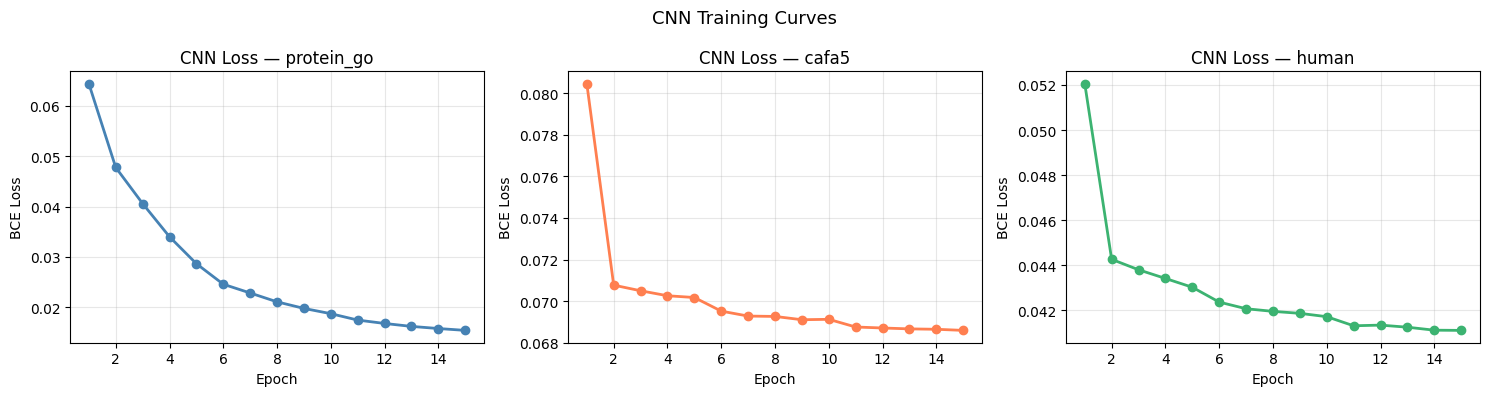

In [126]:
# ── CNN Training Loss Curves ──────────────────────────────────
if cnn_losses:
    fig, axes = plt.subplots(1, len(cnn_losses), figsize=(5 * len(cnn_losses), 4))
    if len(cnn_losses) == 1:
        axes = [axes]
    colors = ["steelblue", "coral", "mediumseagreen"]
    for ax, (ds_name, losses), color in zip(axes, cnn_losses.items(), colors):
        if losses:
            ax.plot(range(1, len(losses)+1), losses, marker="o", color=color, linewidth=2)
            ax.set_title(f"CNN Loss — {ds_name}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("BCE Loss")
            ax.grid(alpha=0.3)
    plt.suptitle("CNN Training Curves", fontsize=13)
    plt.tight_layout()
    plt.savefig("./outputs/cnn_loss_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

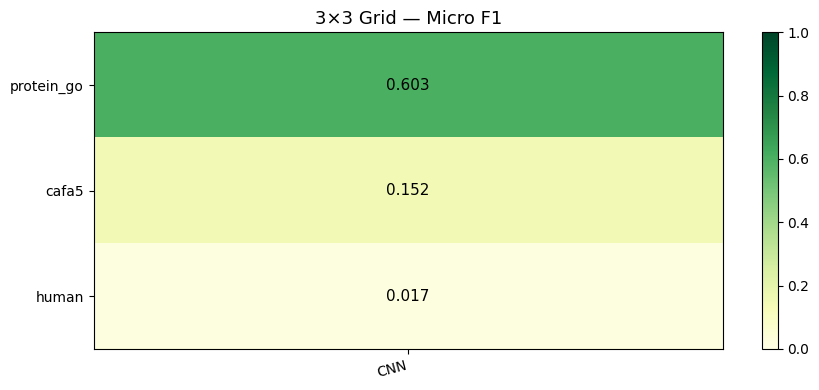

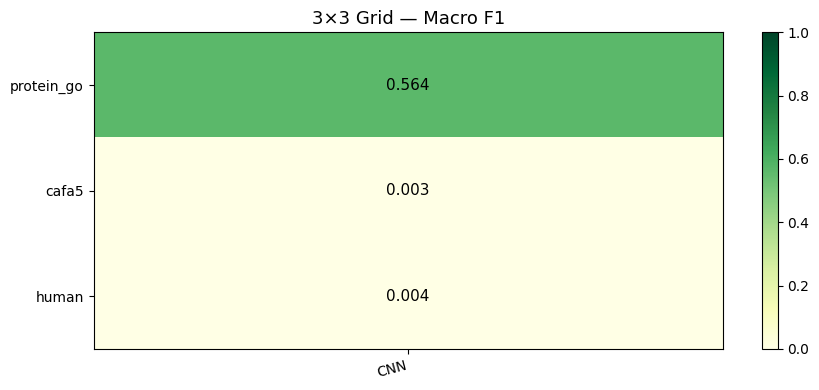

In [127]:
# ── 3×3 Heatmaps — Micro F1 and Macro F1 ─────────────────────
ds_names = list(all_results.keys())
MODEL_NAMES = ["CNN"] # <-- Add logistic regression and SVM

if ds_names:
    for metric in ["Micro F1", "Macro F1"]:
        matrix = np.array(
            [[all_results[ds][m][metric] for m in MODEL_NAMES] for ds in ds_names],
            dtype=object
        )
        matrix_num = np.where(matrix == "N/A", 0, matrix).astype(float)

        fig, ax = plt.subplots(figsize=(9, 4))
        im = ax.imshow(matrix_num, vmin=0, vmax=1, cmap="YlGn", aspect="auto")
        ax.set_xticks(range(len(MODEL_NAMES)))
        ax.set_yticks(range(len(ds_names)))
        ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
        ax.set_yticklabels(ds_names)
        ax.set_title(f"3×3 Grid — {metric}", fontsize=13)
        plt.colorbar(im, ax=ax)
        for i in range(len(ds_names)):
            for j in range(len(MODEL_NAMES)):
                val = matrix[i, j]
                txt = f"{float(val):.3f}" if val != "N/A" else "N/A"
                ax.text(j, i, txt, ha="center", va="center", fontsize=11,
                        color="white" if val != "N/A" and float(val) >= 0.7 else "black")
        plt.tight_layout()
        plt.savefig(f"./outputs/heatmap_{metric.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

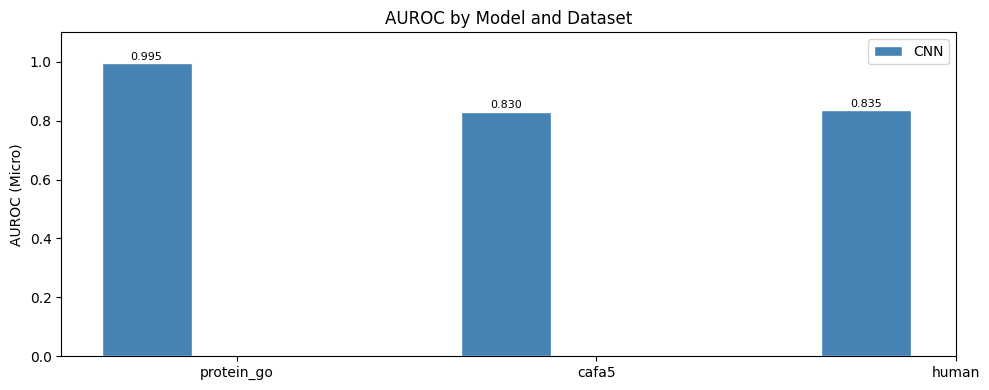

In [128]:
# ── AUROC Bar Chart ───────────────────────────────────────────
if ds_names:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(ds_names))
    width  = 0.25
    colors = ["steelblue", "coral", "mediumseagreen"]

    for i, (model, color) in enumerate(zip(MODEL_NAMES, colors)):
        aurocs = [
            all_results[ds][model]["AUROC"] if all_results[ds][model]["AUROC"] != "N/A" else 0
            for ds in ds_names
        ]
        bars = ax.bar(x + i * width, aurocs, width, label=model, color=color, edgecolor="white")
        for bar, val in zip(bars, aurocs):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(ds_names)
    ax.set_ylabel("AUROC (Micro)")
    ax.set_ylim(0, 1.1)
    ax.set_title("AUROC by Model and Dataset")
    ax.legend()
    plt.tight_layout()
    plt.savefig("./outputs/auroc_bar_chart.png", dpi=150, bbox_inches="tight")
    plt.show()

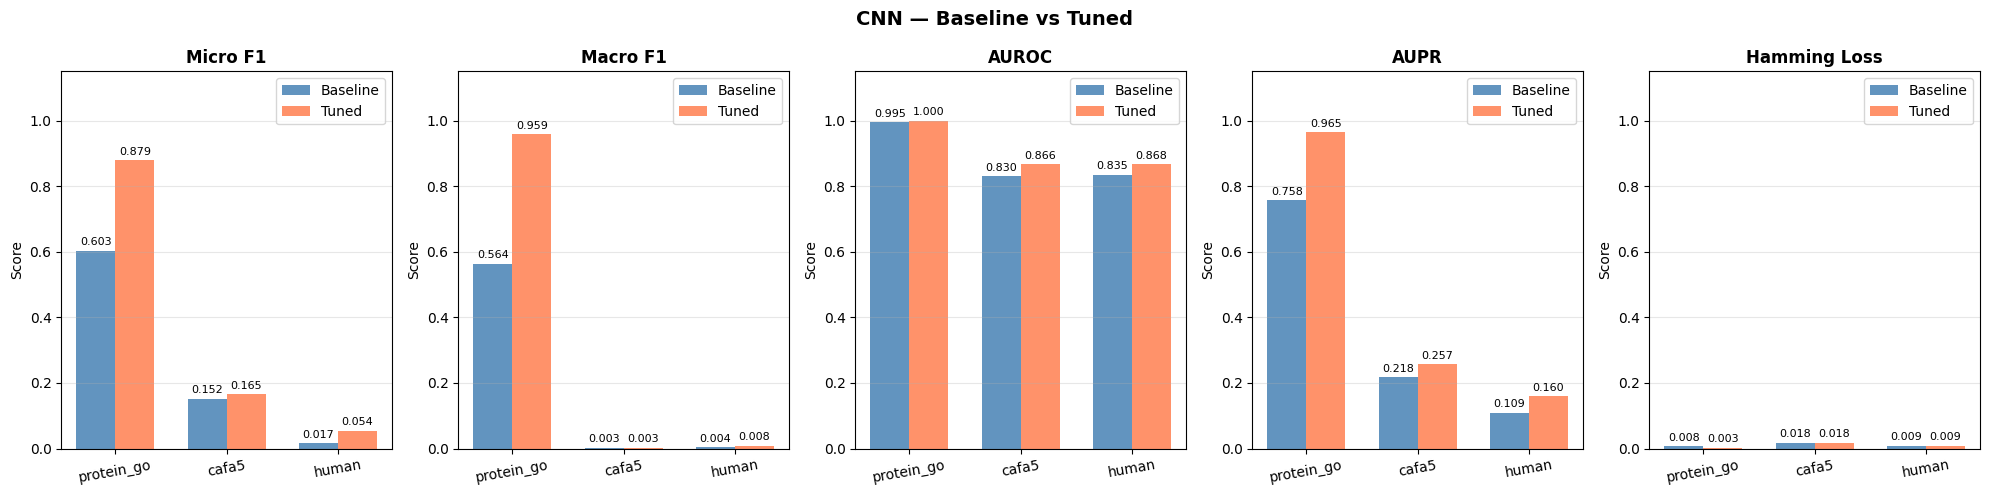

In [129]:
# CNN Baseline vs Tuned 

metrics = ["Micro F1", "Macro F1", "AUROC", "AUPR", "Hamming Loss"]
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    base  = [baseline_vals[ds][metric] for ds in ds_names]
    tuned = [tuned_vals[ds][metric]    for ds in ds_names]
    x = np.arange(len(ds_names))
    width = 0.35

    b1 = ax.bar(x - width/2, base,  width, label="Baseline", color="steelblue", alpha=0.85)
    b2 = ax.bar(x + width/2, tuned, width, label="Tuned",    color="coral",     alpha=0.85)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(ds_names, rotation=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("CNN — Baseline vs Tuned", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./outputs/baseline_vs_tuned.png", dpi=150, bbox_inches="tight")
plt.show()